# Model Output Notebook

<img style="float:center;" src="https://arcticexpansion.vse.gmu.edu/sites/arcticexpansion.vsnet.gmu.edu/files/images/header5d2.png" width=600px>

### ADCIRC-SWAN Output


### Initialize Libraries

In [1]:
import warnings;            import os
import pathlib as pl;       import string
import calendar;            import numpy as np
import pandas as pd;        import xarray as xr
import ruptures as rpt;     import matplotlib.pyplot as plt
import matplotlib as mpl;   import cartopy.crs as ccrs
import cartopy.feature as cfeature
from dask.distributed import Client, LocalCluster
from scipy.stats import pearsonr, genextreme, gumbel_r
from statsmodels.tsa.stattools import adfuller, kpss
from dask import delayed
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tools.sm_exceptions import HypothesisTestWarning
warnings.filterwarnings("ignore")

source $HOME/miniforge3/bin/activate

salloc --ntasks=5 --nodes=1 --partition=normal --time=10:00:00

### Defined Functions

#### Data for this exercise can be found here
https://doi.org/10.17603/ds2-h0fw-2p96

Download the swan_HS.63.nc from one of the 4 folders

---

In [2]:
def compute_keep_idx(sample_path, min_depth, max_depth, bbox=None):
    """
    Return indices of nodes whose depth ∈ [min_depth, max_depth],
    optionally also within (min_x, max_x, min_y, max_y).
    """
    ds = xr.open_dataset(sample_path, engine="netcdf4", mask_and_scale=False)
    depth = ds.depth.values
    fv    = ds.depth.encoding.get("_FillValue", None)

    mask = np.ones_like(depth, dtype=bool)
    if fv is not None:
        mask &= (depth != fv)
    mask &= (depth >= min_depth) & (depth <= max_depth)

    if bbox is not None:
        min_x, max_x, min_y, max_y = bbox
        x, y = ds.x.values, ds.y.values
        mask &= (x >= min_x) & (x <= max_x) & (y >= min_y) & (y <= max_y)

    ds.close()
    return np.where(mask)[0]


def preprocess(ds):
    """Keep only the spin‑up‑free calendar year & shallow nodes."""
    ds = ds.assign_coords(time=pd.to_datetime(ds.time.values))
    year = ds.time.dt.year.values[600]
    mask = ds.time.dt.year == year
    return ds.isel(time=mask, node=keep_idx)


# ─── Change-point detection function ──────────────────────────────────────────
def detect_cp_annual(y, years_array, n_bkps=1):
    """
    Identify one change-point in a 1D annual series using ruptures.
    Returns the corresponding year or NaN if no valid break.
    """
    # need at least 5 valid points
    if np.sum(~np.isnan(y)) < 5:
        return np.nan

    algo = rpt.Binseg(model='rbf').fit(y.reshape(-1, 1))
    bkps = algo.predict(n_bkps=n_bkps)  # e.g., [idx]
    cp   = bkps[0]

    # ensure break is interior
    if 0 < cp < len(years_array):
        return years_array[cp]
    return np.nan

def test_stationarity(arr, alpha=0.05):
    """
    Returns (is_stationary, p_adf, p_kpss) for a 1D array.
    ADF stationary if p_adf < alpha; KPSS stationary if p_kpss > alpha.
    """
    # ADF
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", HypothesisTestWarning)
        try:
            p_adf = adfuller(arr, autolag='AIC')[1]
        except Exception:
            p_adf = 0.0
    # KPSS
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", HypothesisTestWarning)
        try:
            p_kpss = kpss(arr, regression='c', nlags='auto')[1]
        except Exception:
            p_kpss = 1.0

    p_adf  = min(max(p_adf, 0.0), 1.0)
    p_kpss = min(max(p_kpss, 0.0), 1.0)
    return (p_adf < alpha) and (p_kpss > alpha), p_adf, p_kpss


def make_labels(n):
    """Generate ‘a.’, ‘b.’ … ‘z.’, ‘aa.’, … for n panels."""
    labels = []
    alphabet = string.ascii_lowercase
    i = 0
    while len(labels) < n:
        s, x = '', i
        while True:
            s = alphabet[x % 26] + s
            x = x // 26 - 1
            if x < 0:
                break
        labels.append(s + '.')
        i += 1
    return labels


In [3]:
# ─── User‑set parameters ──────────────────────────────────────────────────────
lat1, lat2 = 56, 75
lon1, lon2 = -168.5, -140
root       = '/groups/ORC-CLIMATE/fhrl_repo/Arctic_Database/converted_outputs'
YEARS      = range(2018, 2025)
MIN_DEPTH  = 3
MAX_DEPTH  = 10
bbox       = (lon1, lon2, lat1, lat2)

# compute shallow nodes index
sample_path = f"{root}/2023/swan_HS.63.cf.nc"
keep_idx    = compute_keep_idx(sample_path, MIN_DEPTH, MAX_DEPTH, bbox)
print(f"Keeping {len(keep_idx)} nodes")

Keeping 193441 nodes


In [4]:

# ─── Spin up a Dask cluster ───────────────────────────────────────────────────
n_workers   = int(os.environ.get("SLURM_NTASKS", "45"))
mem_per_cpu = os.environ.get("SLURM_MEM_PER_CPU", "72GB")
cluster     = LocalCluster(
    n_workers=n_workers,
    threads_per_worker=1,
    processes=True,
    memory_limit=mem_per_cpu
)
client = Client(cluster)
print(client)

<Client: 'tcp://127.0.0.1:40581' processes=45 threads=45, memory=2.95 TiB>


In [8]:
client.close(), cluster.close()

(None, None)

In [5]:
paths = [str(pl.Path(root)/str(y)/"swan_HS.63.cf.nc") for y in YEARS]
ds_all = xr.open_mfdataset(
    paths,
    engine="h5netcdf",
    mask_and_scale=True,
    decode_cf=True,
    preprocess=preprocess,
    combine="nested",
    concat_dim="time",
    data_vars=['swan_HS'],               # only load zeta
    chunks={'time': 24},# chunk on both dims
    coords="minimal")                  # minimal coords → time, node, x, y

times  = ds_all.time.values      # length T
hs = ds_all.swan_HS.values
x_all  = ds_all.x.values                          # (n_nodes,)
y_all  = ds_all.y.values                          # (n_nodes,)


2025-10-24 08:49:11,199 - distributed.worker - ERROR - failed during get data with tcp://127.0.0.1:45301 -> tcp://127.0.0.1:44027
Traceback (most recent call last):
  File "/home/tmiesse/miniforge3/envs/general/lib/python3.12/site-packages/tornado/iostream.py", line 861, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
                 ^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tmiesse/miniforge3/envs/general/lib/python3.12/site-packages/tornado/iostream.py", line 1116, in read_from_fd
    return self.socket.recv_into(buf, len(buf))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TimeoutError: [Errno 110] Connection timed out

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/tmiesse/miniforge3/envs/general/lib/python3.12/site-packages/distributed/worker.py", line 1797, in get_data
    response = await comm.read(deserializers=serializers)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tmie

In [6]:
paths = [str(pl.Path(root)/str(y)/"fort.93.cf.nc") for y in YEARS]
ds_all = xr.open_mfdataset(
    paths,
    engine="h5netcdf",
    mask_and_scale=True,
    decode_cf=True,
    preprocess=preprocess,
    combine="nested",
    concat_dim="time",
    data_vars=['iceaf'],               # only load zeta
    chunks={'time': 24},# chunk on both dims
    coords="minimal")                  # minimal coords → time, node, x, y

time_ice  = ds_all.time.values      # length T
iceaf = ds_all.iceaf.values
x_ice  = ds_all.x.values                          # (n_nodes,)
y_ice  = ds_all.y.values                          # (n_nodes,)


2025-10-24 09:14:28,255 - distributed.worker - ERROR - failed during get data with tcp://127.0.0.1:34381 -> tcp://127.0.0.1:43391
Traceback (most recent call last):
  File "/home/tmiesse/miniforge3/envs/general/lib/python3.12/site-packages/tornado/iostream.py", line 861, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
                 ^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tmiesse/miniforge3/envs/general/lib/python3.12/site-packages/tornado/iostream.py", line 1116, in read_from_fd
    return self.socket.recv_into(buf, len(buf))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TimeoutError: [Errno 110] Connection timed out

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/tmiesse/miniforge3/envs/general/lib/python3.12/site-packages/distributed/worker.py", line 1797, in get_data
    response = await comm.read(deserializers=serializers)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tmie

#### Read metadata within netcdf file

_____________________________________

##### plot timeseries of the Hs 

In [ ]:
root2       = pl.Path('/scratch/tmiesse/project/satellite/atl12')
files = list(root2.glob('*.h5'))

In [ ]:
seg = xr.open_dataset(files[1], group=f"/gt2l/ssh_segments/stats", engine="h5netcdf")

In [ ]:
def extract_atl12_simple(file_path, track_list=['gt1l','gt1r','gt2l','gt2r','gt3l','gt3r']):
    """
    Extract lon, lat, datetime, and swh from ATL12 file using xarray.
    Uses delta_time directly (already datetime64).
    """
    lons, lats, hs_all, times = [], [], [], []

    for t in track_list:
        try:
            seg = xr.open_dataset(file_path, group=f"/{t}/ssh_segments", engine="h5netcdf")
            lon = seg["longitude"].values
            lat = seg["latitude"].values
            time = pd.to_datetime(seg["delta_time"].values)  # already datetime64
            seg.close()

            h = xr.open_dataset(file_path, group=f"/{t}/ssh_segments/heights", engine="h5netcdf")
            hs = h["swh"].values
            h.close()

            mask = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(hs)
            if mask.any():
                lons.append(lon[mask])
                lats.append(lat[mask])
                hs_all.append(hs[mask])
                times.append(time[mask])

        except Exception:
            continue

    if lons:
        return (np.concatenate(lons), np.concatenate(lats),
                np.concatenate(hs_all), np.concatenate(times))
    return None, None, None, None

# Make delayed tasks for each file
tasks = [delayed(extract_atl12_simple)(str(f)) for f in files[:]]

# Compute in parallel on your cluster
results = client.compute(tasks, sync=True)

In [ ]:
# Drop None and flatten
atl12_all = []
for r in results:
    if r[0] is None:
        continue
    lon, lat, hs_obs, time_obs = r
    df = pd.DataFrame({
        "lon": lon,
        "lat": lat,
        "time": pd.to_datetime(time_obs),
        "hs_obs": hs_obs
    })
    atl12_all.append(df)

df_atl12 = pd.concat(atl12_all, ignore_index=True)
df_atl12.to_csv('/scratch/tmiesse/project/satellite/atl12_extracted.csv')

In [ ]:
root2 = pl.Path('/scratch/tmiesse/project/satellite')
files = list(root2.rglob('*.nc'))
HS_VAR   = "swh_denoised"                 # or "swh_adjusted" / "swh_denoised"
BBOX     = (-175, -135.0, 50.0, 80.0)   # optional; set to None to disable

In [ ]:
def extract_esa_points(path, hs_var=HS_VAR, bbox=BBOX):
    """
    Return a tidy DataFrame with columns: lon, lat, time, hs, file, satellite (if present).
    Skips files with missing vars or no valid finite points.
    """
    try:
        ds = xr.open_dataset(path, decode_cf=True, mask_and_scale=True)
    except Exception:
        return None

    # lon/lat/time
    lon = ds["lon"].values if "lon" in ds else ds["longitude"].values
    lat = ds["lat"].values if "lat" in ds else ds["latitude"].values
    t   = ds["time"].values  # already datetime64[ns] per your printout

    # hs (prefer chosen, fallback to 'swh')
    if hs_var not in ds:
        hs_var = "swh"
        if hs_var not in ds:
            ds.close()
            return None
    hs = ds[hs_var].values

    # optional satellite ID (if present)
    sat = ds["satellite"].values if "satellite" in ds else None
    ds.close()

    # finite mask
    m = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(hs)
    if not m.any():
        return None
    lon, lat, t, hs = lon[m], lat[m], t[m], hs[m]
    sat = sat[m] if sat is not None else None

    # optional bbox
    if bbox is not None:
        lo1, lo2, la1, la2 = bbox
        mb = (lon >= lo1) & (lon <= lo2) & (lat >= la1) & (lat <= la2)
        if not mb.any():
            return None
        lon, lat, t, hs = lon[mb], lat[mb], t[mb], hs[mb]
        sat = sat[mb] if sat is not None else None

    df = pd.DataFrame({
        "lon": lon,
        "lat": lat,
        "time": pd.to_datetime(t),
        "hs": hs,
        "file": pl.Path(path).name
    })
    if sat is not None:
        # satellite often stored as small ints; keep as int
        df["satellite"] = sat.astype(np.int64)
    return df

In [ ]:
tasks   = [delayed(extract_esa_points)(fp) for fp in files]
results = client.compute(tasks, sync=True)

dfs = [r for r in results if r is not None and len(r)]
df_esa = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame(columns=["lon","lat","time","hs","file","satellite"])
df_esa.to_csv('/scratch/tmiesse/project/satellite/esa_extracted.csv')

In [7]:
df_atl12 = pd.read_csv('/scratch/tmiesse/project/satellite/atl12_extracted.csv', parse_dates=['time'])
df_esa = pd.read_csv('/scratch/tmiesse/project/satellite/esa_extracted.csv', parse_dates=['time'])

In [8]:

# 1) Build KDTree for model nodes
tree = cKDTree(np.column_stack([x_all, y_all]))   # x_all=lon, y_all=lat

# Great-circle distance (meters), vectorized
def haversine_m(lon1, lat1, lon2, lat2):
    R = 6371000.0
    lon1 = np.radians(lon1); lat1 = np.radians(lat1)
    lon2 = np.radians(lon2); lat2 = np.radians(lat2)
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 2.0*R*np.arcsin(np.sqrt(a))

def nearest_time_index(mod_time, t_obs):  # both are datetime64[ns]
    idx = np.searchsorted(mod_time, t_obs)
    idx = np.clip(idx, 1, len(mod_time)-1)
    left  = mod_time[idx-1]
    right = mod_time[idx]
    take_right = (t_obs - left) > (right - t_obs)
    return np.where(take_right, idx, idx-1)


In [9]:
MAX_DIST_M = 100.0  # hard cutoff

def match_to_model_100m(df, hs_col="hs"):
    """
    df must have columns: lon, lat, time, and hs_col (satellite Hs).
    Adds model match ONLY if nearest node is within 100 m; others dropped.
    Returns a new filtered dataframe with:
      ['lon','lat','time',hs_col,'model_node','model_time','hs_mod','dist_m']
    """
    # Nearest node in degrees (fast)
    coords = np.column_stack([df["lon"].values, df["lat"].values])
    _, nodes = tree.query(coords, k=1)

    # Precise distance in meters to that node
    node_lon = x_all[nodes]
    node_lat = y_all[nodes]
    dist_m = haversine_m(df["lon"].values, df["lat"].values, node_lon, node_lat)

    # Keep only matches within 100 m
    keep = dist_m <= MAX_DIST_M
    if not np.any(keep):
        return df.iloc[0:0].copy()  # empty frame with same columns

    nodes  = nodes[keep]
    dist_m = dist_m[keep]
    t_obs  = df["time"].values[keep]

    # Nearest model time index (vectorized)
    t_idx = nearest_time_index(times, t_obs)

    # Pull model Hs at (t_idx, nodes)
    hs_mod_sel = hs[t_idx, nodes]

    out = pd.DataFrame({
        "lon": df["lon"].values[keep],
        "lat": df["lat"].values[keep],
        "time": pd.to_datetime(t_obs),
        hs_col: df[hs_col].values[keep],
        "model_node": nodes.astype(np.int64),
        "model_time": pd.to_datetime(times[t_idx]),
        "hs_mod": hs_mod_sel,
        "dist_m": dist_m
    })
    return out


In [10]:
df_atl12_matched= match_to_model_100m(df_atl12, hs_col="hs_obs")

# ESA uses 'hs' in your df
df_esa_matched   = match_to_model_100m(df_esa,   hs_col="hs")

In [ ]:
obs1 = df_atl12_matched["hs_obs"].values
mod1 = df_atl12_matched["hs_mod"].values

obs2 = df_esa_matched["hs"].values
mod2 = df_esa_matched["hs_mod"].values

# Drop NaNs
mask1 = np.isfinite(obs1) & np.isfinite(mod1)
obs1, mod1 = obs1[mask1], mod1[mask1]

mask2 = np.isfinite(obs2) & np.isfinite(mod2)
obs2, mod2 = obs2[mask2], mod2[mask2]

rmse1 = np.sqrt(mean_squared_error(obs1, mod1))
bias1 = np.mean(mod1 - obs1)

# ESA metrics
rmse2 = np.sqrt(mean_squared_error(obs2, mod2))
bias2 = np.mean(mod2 - obs2)

vmin,vmax = 0, 4
# 1:1 line range

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(obs1, mod1,c='purple', s=10, alpha=0.4, edgecolor="none", label="Icesat - Model")
ax.scatter(obs2, mod2,c='g', s=10, alpha=0.4, edgecolor="none", label="ESA - Model")
# 1:1 line
ax.plot([vmin, vmax], [vmin, vmax], "k--", lw=1.5,)
textstr = (f"ICESat-2 → RMSE={rmse1:.2f} m, Bias={bias1:.2f} m\n"
           f"ESA      → RMSE={rmse2:.2f} m, Bias={bias2:.2f} m")

ax.text(0.05, 0.95, textstr, transform=ax.transAxes,
        fontsize=11, va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
# Labels & formatting
ax.set_xlabel("Observed Hs (m)"),ax.set_ylabel("Model Hs (m)")

ax.set_xlim(vmin, vmax),ax.set_ylim(vmin, vmax)
ax.legend( loc="upper left", fontsize=12, bbox_to_anchor=(0.1,-0.1),ncol=2, frameon=False)
ax.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.savefig("/scratch/tmiesse/project/satellite/figures/hs_comp_no_filter.png", dpi=300)
plt.show()


In [11]:
def _nearest_time_index(sorted_time_axis, query_times):
    """Vectorized nearest-index on a sorted datetime64 axis."""
    idx = np.searchsorted(sorted_time_axis, query_times)
    idx = np.clip(idx, 1, len(sorted_time_axis)-1)
    left  = sorted_time_axis[idx-1]
    right = sorted_time_axis[idx]
    take_right = (query_times - left) > (right - query_times)
    return np.where(take_right, idx, idx-1)

def apply_ice_mask(df, time_axis, ice_array, threshold=0.10, drop=False, ice_col="iceaf"):
    """
    For each row in df, look up ice at (model_time, model_node).
    If ice > threshold, set hs_mod = NaN (drop=False) or drop the row (drop=True).

    df must contain: ['model_time', 'model_node', 'hs_mod'].
    time_axis: datetime64[ns] array for ice times (sorted).
    ice_array: 2D array [time, node] of ice concentration.
    threshold: 0.10 means 10%. If ice_array is in 0..100, it will auto-normalize.
    """
    # 1) time & node index vectors
    qt = df["model_time"].values.astype("datetime64[ns]")
    ni = _nearest_time_index(time_axis, qt)
    nj = df["model_node"].values.astype(int)

    # 2) gather ice values
    ice_vals = ice_array[ni, nj]

    # 3) normalize to 0..1 if array appears in percent
    if np.nanmax(ice_vals) > 1.0:
        ice_vals = ice_vals / 100.0

    # 4) mask logic
    open_water = np.asarray(ice_vals) <= threshold

    out = df.copy()
    out[ice_col] = ice_vals

    if drop:
        out = out[open_water].reset_index(drop=True)
    else:
        # set model waves to NaN where sea ice > threshold
        out.loc[~open_water, "hs_mod"] = np.nan

    return out


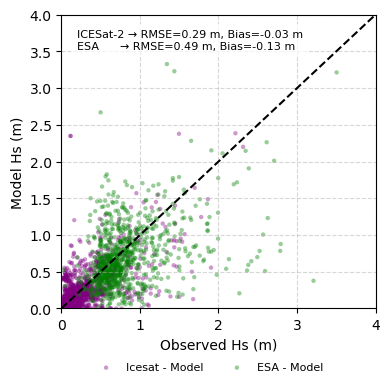

In [12]:
df_atl12_masked = apply_ice_mask(df_atl12_matched, time_ice, iceaf, threshold=0.01, drop=False)
df_esa_masked   = apply_ice_mask(df_esa_matched,   time_ice, iceaf, threshold=0.01, drop=False)

obs1 = df_atl12_masked["hs_obs"].values
mod1 = df_atl12_masked["hs_mod"].values

obs2 = df_esa_masked["hs"].values
mod2 = df_esa_masked["hs_mod"].values

all_obs = np.concatenate([obs1, obs2])
all_mod = np.concatenate([mod1, mod2])

# perpendicular distances from 1:1 line


mask1 = np.isfinite(obs1) & np.isfinite(mod1)
obs1, mod1 = obs1[mask1], mod1[mask1]

mask2 = np.isfinite(obs2) & np.isfinite(mod2)
obs2, mod2 = obs2[mask2], mod2[mask2]

rmse1 = np.sqrt(mean_squared_error(obs1, mod1))
bias1 = np.mean(mod1 - obs1)

# ESA metrics
rmse2 = np.sqrt(mean_squared_error(obs2, mod2))
bias2 = np.mean(mod2 - obs2)

vmin,vmax = 0, 4
# 1:1 line range

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(obs1, mod1,c='purple', s=10, alpha=0.4, edgecolor="none", label="Icesat - Model")
ax.scatter(obs2, mod2,c='g', s=10, alpha=0.4, edgecolor="none", label="ESA - Model")


ax.plot([vmin, vmax], [vmin, vmax], "k--", lw=1.5,)
textstr = (f"ICESat-2 → RMSE={rmse1:.2f} m, Bias={bias1:.2f} m\n"
           f"ESA      → RMSE={rmse2:.2f} m, Bias={bias2:.2f} m")


ax.text(0.05, 0.95, textstr, transform=ax.transAxes,
        fontsize=8, va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
# Labels & formatting
ax.set_xlabel("Observed Hs (m)")
ax.set_ylabel("Model Hs (m)")

ax.set_xlim(vmin, vmax)
ax.set_ylim(vmin, vmax)
ax.legend( loc="upper left", fontsize=8, bbox_to_anchor=(0.075,-0.15),ncol=2, frameon=False)
ax.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.savefig("/scratch/tmiesse/project/satellite/figures/hs_comp_w_filter.png", dpi=300)
plt.show()

In [13]:
import matplotlib as mpl

In [14]:
obs1 = df_atl12_masked["hs_obs"].values
mod1 = df_atl12_masked["hs_mod"].values
bias1 = mod1 - obs1

obs2 = df_esa_masked["hs"].values
mod2 = df_esa_masked["hs_mod"].values
bias2 = mod2 - obs2
bins = np.linspace(-1, 1, 6)
cmap = plt.get_cmap('plasma', len(bins)-1)
norm = mpl.colors.BoundaryNorm(bins, len(bins)-1)
normalize = mpl.colors.Normalize(vmin=-1, vmax=1)
mask1,mask2 = np.isfinite(bias1), np.isfinite(bias2)  
bias1,bias2 = bias1[mask1], bias2[mask2]
colors1 = [cmap(norm(b)) for b in bias1]
colors2 = [cmap(norm(b)) for b in bias2]

lats1,lons1 = df_atl12_masked["lat"].values, df_atl12_masked["lon"].values
lats2,lons2 = df_esa_masked["lat"].values, df_esa_masked["lon"].values

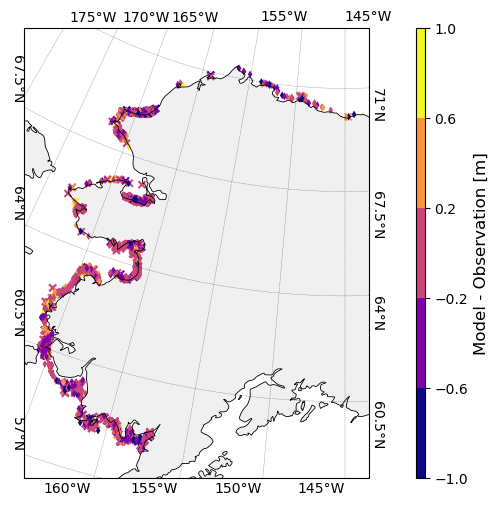

In [22]:
import cartopy.crs as ccrs
import cartopy as cart
import cartopy.feature as cfeature
from matplotlib.collections import LineCollection

# ---- helpers ----------------------------------------------------------
def wrap180(lon):
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180.0) % 360.0) - 180.0



# --- plot ---
lon1, lon2 = -165, -143.5
lat1, lat2 = 58, 72

#proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(6, 5))
proj = ccrs.NorthPolarStereo(central_longitude=-145)
ax = plt.axes([0.05,0.05,0.9,.9],projection=proj)
ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())

# basemap features
ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor="#f0f0f0")
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.4, alpha=0.6)

gl = ax.gridlines(xlocs=np.arange(-190, -100, 5),
                  ylocs=np.arange(-90, 90, 3.5),
                  draw_labels=True, linewidth=0.3, color="black", alpha=0.5,
                  y_inline=False, linestyle="--", zorder=20)
gl.xlabels_top = False
gl.xlabels_bottom = True
gl.xlabel_style = {'rotation': 0}
gl.ylabels_left = False
gl.ylabels_right = True
gl.ylabel_style = {'rotation': -90}
gl.ypadding = 1.25
gl.xformatter = cart.mpl.gridliner.LONGITUDE_FORMATTER
gl.xpadding = 8

# scatter plot of ATL12 points
sc1 = ax.scatter(lons1[mask1], lats1[mask1], c=colors1, s=25,marker='x',
                transform=ccrs.PlateCarree(), alpha=1, edgecolor="none")
sc2 = ax.scatter(lons2[mask2], lats2[mask2], c=colors2, s=15,marker='d',
                transform=ccrs.PlateCarree(), alpha=1, edgecolor="none")
cax1 = fig.add_axes([0.865, 0.05, 0.015, 0.9])
cb1  = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cax1, orientation='vertical',
    boundaries=bins, ticks=bins,ax=ax
)
cb1.set_label('Model - Observation [m]', fontsize=12)
plt.tight_layout()
plt.savefig("/scratch/tmiesse/project/satellite/figures/bias_map.png", dpi=600)
plt.show()

In [ ]:
def _wrap180(lon):
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180.0) % 360.0) - 180.0

def tag_points_with_sea(df, seas_gdf, lon_col="lon", lat_col="lat"):
    gdf_pts = gpd.GeoDataFrame(
        df.copy(),
        geometry=gpd.points_from_xy(_wrap180(df[lon_col].values), df[lat_col].values),
        crs="EPSG:4326"
    )
    joined = gpd.sjoin(gdf_pts, seas_gdf, how="left", predicate="within")
    out = pd.DataFrame(joined.drop(columns="geometry"))
    return out

In [ ]:
import geopandas as gpd
seas_all = gpd.read_file('/scratch/tmiesse/project/World_Seas_IHO_v3/World_Seas_IHO_v3.shp')

In [ ]:
target_seas = ["Chukchi Sea", "Beaufort Sea", "Bering Sea"]  # adjust if your file uses different strings
seas_gdf = seas_all[seas_all["NAME"].isin(target_seas)][["NAME","geometry"]].copy()
seas_gdf = seas_gdf.rename(columns={"NAME":"sea_name"}).reset_index(drop=True)

In [ ]:
atl12_tag = tag_points_with_sea(df_atl12_masked, seas_gdf, lon_col="lon", lat_col="lat")
atl12_tag = atl12_tag[atl12_tag["sea_name"].notna()].copy()
atl12_tag["obs"] = atl12_tag["hs_obs"].astype(float)
atl12_tag["mod"] = atl12_tag["hs_mod"].astype(float)

# ESA matched (expects: lon, lat, time, hs, hs_mod)
esa_tag = tag_points_with_sea(df_esa_masked, seas_gdf, lon_col="lon", lat_col="lat")
esa_tag = esa_tag[esa_tag["sea_name"].notna()].copy()
esa_tag["obs"] = esa_tag["hs"].astype(float)
esa_tag["mod"] = esa_tag["hs_mod"].astype(float)

In [ ]:
sea_filter = [ "Bering Sea"]  # or a single string like "Chukchi Sea""Chukchi Sea"]#,

if isinstance(sea_filter, str):
    atl12_sel = atl12_tag[atl12_tag["sea_name"] == sea_filter].copy()
    esa_sel   = esa_tag[esa_tag["sea_name"] == sea_filter].copy()
else:
    atl12_sel = atl12_tag[atl12_tag["sea_name"].isin(sea_filter)].copy()
    esa_sel   = esa_tag[esa_tag["sea_name"].isin(sea_filter)].copy()

def rmse_bias(df):
    m = np.isfinite(df["obs"].values) & np.isfinite(df["mod"].values)
    if not m.any():
        return np.nan, np.nan, 0
    rmse = float(np.sqrt(np.mean((df["mod"].values[m] - df["obs"].values[m])**2)))
    bias = float(np.mean(df["mod"].values[m] - df["obs"].values[m]))
    return rmse, bias, int(m.sum())

rmse1, bias1, n1 = rmse_bias(atl12_sel)
rmse2, bias2, n2 = rmse_bias(esa_sel)

print("ICESat-2:", {"RMSE": rmse1, "Bias": bias1, "N": n1})
print("ESA    :", {"RMSE": rmse2, "Bias": bias2, "N": n2})

In [ ]:

vmin,vmax = 0, 4
# 1:1 line range

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(atl12_sel["obs"], atl12_sel["mod"],c='purple', s=10, alpha=0.35, edgecolor="none", label="ICESat-2")
ax.scatter(esa_sel["obs"], esa_sel["mod"],c='g', s=10, alpha=0.35, edgecolor="none", label="ESA")

# 1:1 line
ax.plot([vmin, vmax], [vmin, vmax], "k--", lw=1.5,)
textstr = (f"ICESat-2 → RMSE={rmse1:.2f} m, Bias={bias1:.2f} m\n"
           f"ESA      → RMSE={rmse2:.2f} m, Bias={bias2:.2f} m")
textstr = f"Icesat -> RMSE={rmse1:.2f}  Bias={bias1:.2f} \n"\
          f"ESA -> RMSE={rmse2:.2f}  Bias={bias2:.2f}"
ax.text(0.05, 0.95, textstr, transform=ax.transAxes,
        fontsize=11, va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
# Labels & formatting
ax.set_xlabel("Observed Hs (m)")
ax.set_ylabel("Model Hs (m)")

ax.set_xlim(vmin, vmax)
ax.set_ylim(vmin, vmax)
ax.legend( loc="upper left", fontsize=12, bbox_to_anchor=(0.1,-0.1),ncol=2, frameon=False)
ax.grid(True, ls="--", alpha=0.5)
ax.set_title(", ".join(sea_filter), fontsize=14)
plt.tight_layout()
plt.savefig("/scratch/tmiesse/project/satellite/figures/hs_comp_w_filter_bering.png", dpi=300)
plt.show()

In [ ]:
def _wrap180(lon):
    """Normalize longitude to [-180, 180)."""
    return ((lon + 180.0) % 360.0) - 180.0

def _to_unit_sphere(lon_deg, lat_deg):
    """lon/lat (deg) -> 3D unit sphere coords for KDTree."""
    lon = np.radians(lon_deg)
    lat = np.radians(lat_deg)
    cl  = np.cos(lat)
    return np.column_stack([cl*np.cos(lon), cl*np.sin(lon), np.sin(lat)])

def _haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    lon1 = np.radians(lon1); lat1 = np.radians(lat1)
    lon2 = np.radians(lon2); lat2 = np.radians(lat2)
    dlon = lon2 - lon1; dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def compare_atl12_vs_esa_raw(
    df_atl12, df_esa,
    max_dist_km=50.0,         # start a bit loose; tighten later (e.g., 25 km)
    max_time_min=120.0,       # start a bit loose; tighten later (e.g., 60 min)
    atl12_hs_col="hs_obs",    # ATL12 Hs column name in df_atl12
    esa_hs_col="hs"           # ESA   Hs column name in df_esa
):
    """
    Pair ATL12 points to nearest ESA points (space-first), then filter by time.
    Returns tidy DataFrame with both Hs and proximity metrics.
    """
    # 1) basic clean
    A = df_atl12.dropna(subset=["lon","lat","time", atl12_hs_col]).copy()
    E = df_esa   .dropna(subset=["lon","lat","time", esa_hs_col]).copy()
    if A.empty or E.empty:
        return pd.DataFrame(columns=[
            "lon_icesat","lat_icesat","time_icesat","hs_icesat",
            "lon_esa","lat_esa","time_esa","hs_esa",
            "dist_km","dt_min","idx_esa"
        ])

    # 2) wrap longitudes consistently
    A["lon"] = _wrap180(A["lon"].values)
    E["lon"] = _wrap180(E["lon"].values)

    # 3) KDTree on ESA (space)
    tree = cKDTree(_to_unit_sphere(E.lon.values, E.lat.values))
    _, idx_spatial = tree.query(_to_unit_sphere(A.lon.values, A.lat.values), k=1)

    # 4) compute true distance & time delta
    lon_e = E.lon.values[idx_spatial]
    lat_e = E.lat.values[idx_spatial]
    tim_e = E.time.values[idx_spatial]

    dist_km = _haversine_km(A.lon.values, A.lat.values, lon_e, lat_e)
    dt_min  = np.abs((A.time.values - tim_e) / np.timedelta64(1, "m")).astype(float)

    # 5) filter by thresholds
    keep = (dist_km <= max_dist_km) & (dt_min <= max_time_min)
    if not np.any(keep):
        return pd.DataFrame(columns=[
            "lon_icesat","lat_icesat","time_icesat","hs_icesat",
            "lon_esa","lat_esa","time_esa","hs_esa","dist_km","dt_min","idx_esa"
        ])

    # 6) build paired dataframe
    out = pd.DataFrame({
        "lon_icesat": A.lon.values[keep],
        "lat_icesat": A.lat.values[keep],
        "time_icesat": pd.to_datetime(A.time.values[keep]),
        "hs_icesat": A[atl12_hs_col].values[keep],

        "lon_esa": lon_e[keep],
        "lat_esa": lat_e[keep],
        "time_esa": pd.to_datetime(tim_e[keep]),
        "hs_esa": E[esa_hs_col].values[idx_spatial[keep]],

        "dist_km": dist_km[keep],
        "dt_min": dt_min[keep],
        "idx_esa": idx_spatial[keep].astype(int),
    })
    return out

In [ ]:
df_sat_compare = compare_atl12_vs_esa_raw(
    df_atl12, df_esa,
    max_dist_km=1.50,      # try 50 km / 120 min first to confirm overlap
    max_time_min=120.0,    # then tighten to (25 km, 60 min), etc.
    atl12_hs_col="hs_obs",
    esa_hs_col="hs"
)
df_sat_compare.to_csv('/scratch/tmiesse/project/satellite/atl12_esa_comparison.csv')

In [ ]:
obs1 = df_sat_compare["hs_esa"].values
mod1 = df_sat_compare["hs_icesat"].values


rmse1 = np.sqrt(mean_squared_error(obs1, mod1))
bias1 = np.mean(mod1 - obs1)



vmin,vmax = 0, 5
# 1:1 line range

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(obs1, mod1,c='b', s=10, alpha=0.4, edgecolor="none", label="Icesat - ESA")

# 1:1 line
ax.plot([vmin, vmax], [vmin, vmax], "k--", lw=1.5,)
textstr = (f"ICESat-2 → RMSE={rmse1:.2f} m, Bias={bias1:.2f} m")

ax.text(0.05, 0.95, textstr, transform=ax.transAxes,
        fontsize=11, va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
# Labels & formatting
ax.set_xlabel("ESA Hs (m)")
ax.set_ylabel("Icesat Hs (m)")

ax.set_xlim(vmin, vmax)
ax.set_ylim(vmin, vmax)
ax.legend( loc="upper left", fontsize=12, bbox_to_anchor=(0.1,-0.1),ncol=2, frameon=False)
ax.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.savefig("/scratch/tmiesse/project/satellite/figures/hs_sat.png", dpi=300)
plt.show()

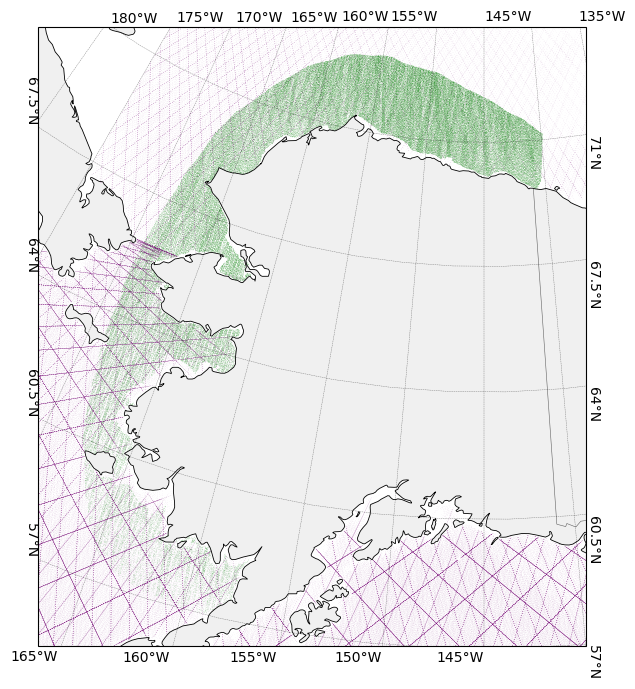

In [21]:
import cartopy.crs as ccrs
import cartopy as cart
import cartopy.feature as cfeature
from matplotlib.collections import LineCollection

# ---- helpers ----------------------------------------------------------
def wrap180(lon):
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180.0) % 360.0) - 180.0

# --- prep your dataframe ---
df = df_atl12.dropna(subset=["lon","lat"]).copy()
df["lon"] = wrap180(df["lon"].values)

# optional: color by beam if available
color_map = {
    "gt1l":"tab:blue","gt1r":"tab:blue",
    "gt2l":"tab:orange","gt2r":"tab:orange",
    "gt3l":"tab:green","gt3r":"tab:green",
}
if "gt" in df.columns:
    colors = df["gt"].map(color_map).fillna("purple").values
else:
    colors = "black"

# --- plot ---
lon1, lon2 = -167.5, -140
lat1, lat2 = 57, 73

#proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(7, 7))
proj = ccrs.NorthPolarStereo(central_longitude=-145)
ax = plt.axes(projection=proj)
ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())

# basemap features
ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor="#f0f0f0")
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.4, alpha=0.6)

gl = ax.gridlines(xlocs=np.arange(-190, -100, 5),
                  ylocs=np.arange(-90, 90, 3.5),
                  draw_labels=True, linewidth=0.3, color="black", alpha=0.5,
                  y_inline=False, linestyle="--", zorder=20)
gl.xlabels_top = False
gl.xlabels_bottom = True
gl.xlabel_style = {'rotation': 0}
gl.ylabels_left = False
gl.ylabels_right = True
gl.ylabel_style = {'rotation': -90}
gl.ypadding = 1.25
gl.xformatter = cart.mpl.gridliner.LONGITUDE_FORMATTER
gl.xpadding = 8

# scatter plot of ATL12 points
sc = ax.scatter(df["lon"][::10], df["lat"][::10], c='g', s=0.15,marker='.',
                transform=ccrs.PlateCarree(), alpha=1, edgecolor="none")

sc = ax.scatter(df_esa["lon"][::1], df_esa["lat"][::1], c='purple', s=0.1,marker='.',
                transform=ccrs.PlateCarree(), alpha=0.5, edgecolor="none")

plt.tight_layout()
plt.savefig("/scratch/tmiesse/project/satellite/figures/sat_map.png", dpi=300)
plt.show()

In [11]:
obs = pl.Path('/scratch/tmiesse/project/uw_data/wavedata_converted')
ofiles = sorted(list(obs.glob('*.nc')))

In [12]:
def _decode_buoy_time(t_da):
    """Decode buoy time → numpy datetime64[ns]. Handles CF 'since ...' and MATLAB datenum."""
    t = np.asarray(t_da.values)
    # already datetime-like
    if np.issubdtype(t.dtype, np.datetime64):
        return t.astype('datetime64[ns]')

    units = (t_da.attrs.get('units') or '').lower()
    if 'since' in units:
        # CF-style: "<unit> since YYYY-MM-DD ..."
        unit_txt = units.split('since', 1)[0].strip()
        ref_txt  = units.split('since', 1)[1].strip()
        unit_map = {'seconds':'s','second':'s','sec':'s','s':'s',
                    'minutes':'m','minute':'m','min':'m','m':'m',
                    'hours':'h','hour':'h','h':'h',
                    'days':'D','day':'D','d':'D'}
        u = unit_map.get(unit_txt, 'D')
        return (pd.to_datetime(ref_txt) + pd.to_timedelta(t, unit=u)).values.astype('datetime64[ns]')

    # MATLAB datenum (2019 ≈ 737xxx); offset to Unix epoch is 719529 days
    if np.nanmedian(t) > 3e5:
        return pd.to_datetime(t - 719529.0, unit='D', origin='unix').values.astype('datetime64[ns]')

    # Fallback: treat as Unix days
    return pd.to_datetime(t, unit='D', origin='unix').values.astype('datetime64[ns]')

def load_buoy_files_skip_empty(paths):
    """
    Load multiple buoy NetCDFs that share the same variable names.
    Skips files with no 'time' or zero-length time.
    Returns a tidy DataFrame: buoy_id, time, lon, lat, hs, tp, dir, depth, watertemp
    """
    recs = []
    skipped = []
    for p in paths:
        p = pl.Path(p)
        try:
            with xr.open_dataset(p) as ds:
                # require 'time' + expected vars (as coords or data_vars)
                if 'time' not in ds.variables and 'time' not in ds.coords:
                    skipped.append((p.name, "no 'time'"))
                    continue
                if ds['time'].sizes.get('time', ds['time'].sizes.get(ds['time'].dims[0], 0)) == 0:
                    skipped.append((p.name, "empty time"))
                    continue

                t  = _decode_buoy_time(ds['time'])
                lon = np.asarray(ds['lon'].values, dtype=float)
                lat = np.asarray(ds['lat'].values, dtype=float)
                hs  = np.asarray(ds['sigwaveheight'].values, dtype=float)
                tp  = np.asarray(ds['peakwaveperiod'].values, dtype=float)  if 'peakwaveperiod' in ds.variables or 'peakwaveperiod' in ds.coords else np.full(lon.size, np.nan)
                dr  = np.asarray(ds['peakwavedirT'].values, dtype=float)    if 'peakwavedirT'   in ds.variables or 'peakwavedirT'   in ds.coords else np.full(lon.size, np.nan)
                wt  = np.asarray(ds['watertemp'].values, dtype=float)       if 'watertemp'      in ds.variables or 'watertemp'      in ds.coords else np.full(lon.size, np.nan)
                dp  = np.asarray(ds['depth'].values, dtype=float)           if 'depth'          in ds.variables or 'depth'          in ds.coords else np.full(lon.size, np.nan)

                n = min(len(t), len(lon), len(lat), len(hs))  # guard against tiny mismatches
                recs.append(pd.DataFrame({
                    'buoy_id':  p.stem,
                    'time':     pd.to_datetime(t[:n]),
                    'lon':      lon[:n],
                    'lat':      lat[:n],
                    'hs':       hs[:n],
                    'tp':       tp[:n],
                    'dir':      dr[:n],
                    'depth':    dp[:n],
                    'watertemp':wt[:n],
                }))
        except Exception as e:
            skipped.append((p.name, f'error: {e}'))
            continue

    df = pd.concat(recs, ignore_index=True) if recs else pd.DataFrame(
        columns=['buoy_id','time','lon','lat','hs','tp','dir','depth','watertemp']
    )
    df = df.dropna(subset=['time','lon','lat']).sort_values(['buoy_id','time']).reset_index(drop=True)

    if skipped:
        print("Skipped files:", skipped)
    return df

In [13]:
df_buoy = load_buoy_files_skip_empty(ofiles)

Skipped files: [('S3A1.nc', "no 'time'")]


In [141]:
def _wrap180(lon):
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180.0) % 360.0) - 180.0

def _haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    lon1 = np.radians(lon1); lat1 = np.radians(lat1)
    lon2 = np.radians(lon2); lat2 = np.radians(lat2)
    dlon = lon2 - lon1; dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def collocate_atl12_with_buoys(
    df_atl12,         # DataFrame with at least: lon, lat, time, hs_obs
    df_buoy,          # DataFrame with at least: buoy_id, lon, lat, time, hs
    time_pad_minutes=30,
    max_dist_km=20.0
):
    """
    Collocate ICESat-2 ATL12 shots with moving buoy records.
    For each ATL12 shot, picks the nearest-in-time sample from each buoy (within ±time_pad)
    and keeps it only if great-circle distance ≤ max_dist_km.

    Returns a DataFrame with columns:
      ['buoy_id','atl_time','atl_lon','atl_lat','atl_hs',
       'buoy_time','buoy_lon','buoy_lat','buoy_hs','dist_km','dt_min']
    """
    def _wrap180(lon):
        lon = np.asarray(lon, dtype=float)
        return ((lon + 180.0) % 360.0) - 180.0

    def _haversine_km(lon1, lat1, lon2, lat2):
        R = 6371.0
        lon1 = np.radians(lon1); lat1 = np.radians(lat1)
        lon2 = np.radians(lon2); lat2 = np.radians(lat2)
        dlon = lon2 - lon1; dlat = lat2 - lat1
        a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
        return 2.0 * R * np.arcsin(np.sqrt(a))

    # Clean inputs & dtypes
    A = df_atl12.dropna(subset=["lon","lat","time","hs_obs"]).copy()
    A["time"] = pd.to_datetime(A["time"])
    A["lon"]  = _wrap180(A["lon"].values)

    B = df_buoy.dropna(subset=["lon","lat","time","hs"]).copy()
    B["time"] = pd.to_datetime(B["time"])
    B["lon"]  = _wrap180(B["lon"].values)

    pad = pd.to_timedelta(time_pad_minutes, "m")
    out = []

    # Process one buoy at a time (binary search on sorted buoy times)
    for buoy_id, gb in B.groupby("buoy_id"):
        gb = gb.sort_values("time")
        tb = gb["time"].values.astype("datetime64[ns]")
        lonb = gb["lon"].values
        latb = gb["lat"].values
        hsb  = gb["hs"].values

        ta = A["time"].values.astype("datetime64[ns]")

        # nearest-in-time buoy index for each ATL12 time
        idx = np.searchsorted(tb, ta)
        idx = np.clip(idx, 1, tb.size - 1)
        left, right = tb[idx - 1], tb[idx]
        take_right = (ta - left) > (right - ta)
        j = np.where(take_right, idx, idx - 1)

        # time tolerance mask (fixed: compare Timedelta directly)
        dt = np.abs(ta - tb[j])
        keep_t = dt <= pad
        if not keep_t.any():
            continue

        # slice ATL12 & matched buoy samples for those within time window
        lon_a = A["lon"].values[keep_t]
        lat_a = A["lat"].values[keep_t]
        t_a   = A["time"].values[keep_t]
        hs_a  = A["hs_obs"].values[keep_t]

        lon_bb = lonb[j[keep_t]]
        lat_bb = latb[j[keep_t]]
        hs_bb  = hsb[j[keep_t]]
        t_bb   = tb[j[keep_t]]

        # distance tolerance
        dkm = _haversine_km(lon_a, lat_a, lon_bb, lat_bb)
        keep = dkm <= max_dist_km
        if not keep.any():
            continue

        out.append(pd.DataFrame({
            "buoy_id":   buoy_id,
            "atl_time":  t_a[keep],
            "atl_lon":   lon_a[keep],
            "atl_lat":   lat_a[keep],
            "atl_hs":    hs_a[keep],
            "buoy_time": t_bb[keep],
            "buoy_lon":  lon_bb[keep],
            "buoy_lat":  lat_bb[keep],
            "buoy_hs":   hs_bb[keep],
            "dist_km":   dkm[keep].astype(float),
            "dt_min":    (np.abs(t_a[keep] - t_bb[keep]) / np.timedelta64(1,"m")).astype(float),
        }))

    if not out:
        return pd.DataFrame(columns=[
            "buoy_id","atl_time","atl_lon","atl_lat","atl_hs",
            "buoy_time","buoy_lon","buoy_lat","buoy_hs","dist_km","dt_min"
        ])

    df_match = pd.concat(out, ignore_index=True)
    df_match = df_match.dropna(subset=["atl_hs","buoy_hs","atl_lon","atl_lat","buoy_lon","buoy_lat"])
    return df_match.sort_values(["buoy_id","atl_time"]).reset_index(drop=True)


def collocate_buoy_with_model_fast(
    df_buoy,            # cols: buoy_id, lon, lat, time, hs
    x_all, y_all,       # model node coords (1D)
    hs, times,          # hs shape (Nt, Nn) NumPy; times datetime64[ns] (Nt,)
    max_dist_km=5.0,
    max_dt_min=30
):
    """
    KDTree nearest-node + vectorized nearest-time collocation.
    Returns DataFrame with buoy↔model pairs within spatial & temporal tolerances.
    """

    # ---- helpers ----
    def _wrap180(a): return ((np.asarray(a, float) + 180.0) % 360.0) - 180.0
    def _to_unit_sphere(lon_deg, lat_deg):
        lon = np.radians(lon_deg); lat = np.radians(lat_deg)
        c = np.cos(lat); return np.column_stack([c*np.cos(lon), c*np.sin(lon), np.sin(lat)])
    def _arc_km(u, v):
        dot = np.einsum('ij,ij->i', u, v).clip(-1.0, 1.0)
        return 6371.0 * np.arccos(dot)

    # ---- clean inputs ----
    B = df_buoy.dropna(subset=["lon","lat","time","hs"]).copy()
    B["lon"]  = _wrap180(B["lon"].values)
    B["time"] = pd.to_datetime(B["time"]).values.astype("datetime64[ns]")

    Tm = pd.to_datetime(times).astype("datetime64[ns]")  # ensure ns precision

    # ---- KDTree on nodes (unit sphere) ----
    node_xyz = _to_unit_sphere(_wrap180(x_all), y_all)
    kdt = cKDTree(node_xyz)

    out_blocks = []

    # ---- per-buoy vectorized pass ----
    for buoy_id, g in B.groupby("buoy_id"):
        lonb = g["lon"].to_numpy(float)
        latb = g["lat"].to_numpy(float)
        tb   = g["time"].to_numpy()
        hsb  = g["hs"].to_numpy(float)

        # nearest node for all points
        buoy_xyz = _to_unit_sphere(lonb, latb)
        # query once, reuse indices for distance
        dist_idx = kdt.query(buoy_xyz, k=1)[1]
        dist_km  = _arc_km(buoy_xyz, node_xyz[dist_idx])

        keep_space = dist_km <= max_dist_km
        if not keep_space.any():
            continue

        lonb = lonb[keep_space]; latb = latb[keep_space]
        tb   = tb[keep_space];   hsb  = hsb[keep_space]
        jidx = dist_idx[keep_space]
        dkm  = dist_km[keep_space]

        # nearest model time (vectorized)
        idx = np.searchsorted(Tm, tb)
        idx = np.clip(idx, 1, Tm.size - 1)
        left, right = Tm[idx - 1], Tm[idx]
        take_right = (tb - left) > (right - tb)
        kidx = np.where(take_right, idx, idx - 1)

        dt_min = (np.abs(tb - Tm[kidx]) / np.timedelta64(1, "m")).astype(float)
        keep_time = dt_min <= max_dt_min
        if not keep_time.any():
            continue

        lonb = lonb[keep_time]; latb = latb[keep_time]
        tb   = tb[keep_time];   hsb  = hsb[keep_time]
        jidx = jidx[keep_time]; dkm  = dkm[keep_time]
        kidx = kidx[keep_time]; dtm  = dt_min[keep_time]

        # single batched gather (hs is NumPy: shape (Nt, Nn))
        hs_mod = hs[kidx, jidx].astype(float)

        out_blocks.append(pd.DataFrame({
            "buoy_id":    buoy_id,
            "buoy_time":  tb,
            "buoy_lon":   lonb,
            "buoy_lat":   latb,
            "buoy_hs":    hsb,
            "node_id":    jidx.astype(int),
            "node_lon":   x_all[jidx],
            "node_lat":   y_all[jidx],
            "model_time": Tm[kidx],
            "hs_mod":     hs_mod,
            "dist_km":    dkm.astype(float),
            "dt_min":     dtm
        }))

    if not out_blocks:
        return pd.DataFrame(columns=[
            "buoy_id","buoy_time","buoy_lon","buoy_lat","buoy_hs",
            "node_id","node_lon","node_lat","model_time","hs_mod","dist_km","dt_min"
        ])

    return pd.concat(out_blocks, ignore_index=True).sort_values(
        ["buoy_id","buoy_time"]
    ).reset_index(drop=True)
def collocate_buoy_with_esa(
    df_buoy,   # buoy_id, lon, lat, time, hs
    df_esa,    # lon, lat, time, hs
    max_dist_km=20.0,
    max_dt_min=30
):
    """
    Match buoy samples to nearest ESA SWH observations (time+space).
    Returns DataFrame with buoy & ESA pairs.
    """
    def _wrap180(a): return ((np.asarray(a, float) + 180.0) % 360.0) - 180.0
    def _to_unit_sphere(lon, lat):
        lon, lat = np.radians(lon), np.radians(lat)
        c = np.cos(lat)
        return np.column_stack([c*np.cos(lon), c*np.sin(lon), np.sin(lat)])
    def _arc_km(u, v):
        dot = np.einsum('ij,ij->i', u, v).clip(-1, 1)
        return 6371.0 * np.arccos(dot)

    # prepare inputs
    B = df_buoy.dropna(subset=["lon","lat","time","hs"]).copy()
    B["lon"] = _wrap180(B["lon"].values)
    B["time"] = pd.to_datetime(B["time"]).values.astype("datetime64[ns]")

    E = df_esa.dropna(subset=["lon","lat","time","hs"]).copy()
    E["lon"] = _wrap180(E["lon"].values)
    E["time"] = pd.to_datetime(E["time"]).values.astype("datetime64[ns]")

    if E.empty or B.empty:
        return pd.DataFrame(columns=[
            "buoy_id","buoy_time","buoy_lon","buoy_lat","buoy_hs",
            "esa_time","esa_lon","esa_lat","esa_hs","dist_km","dt_min"
        ])

    # KDTree on ESA spatial coords
    esa_xyz = _to_unit_sphere(E["lon"].values, E["lat"].values)
    tree = cKDTree(esa_xyz)

    # match loop
    out = []
    for buoy_id, g in B.groupby("buoy_id"):
        lonb = g["lon"].values
        latb = g["lat"].values
        tb   = g["time"].values
        hsb  = g["hs"].values

        buoy_xyz = _to_unit_sphere(lonb, latb)
        idx = tree.query(buoy_xyz, k=1)[1]

        esa_sel = E.iloc[idx]
        dist_km = _arc_km(buoy_xyz, esa_xyz[idx])
        dt_min  = (np.abs(tb - esa_sel["time"].values) / np.timedelta64(1,"m")).astype(float)

        keep = (dist_km <= max_dist_km) & (dt_min <= max_dt_min)
        if not keep.any():
            continue

        out.append(pd.DataFrame({
            "buoy_id":   buoy_id,
            "buoy_time": tb[keep],
            "buoy_lon":  lonb[keep],
            "buoy_lat":  latb[keep],
            "buoy_hs":   hsb[keep],
            "esa_time":  esa_sel["time"].values[keep],
            "esa_lon":   esa_sel["lon"].values[keep],
            "esa_lat":   esa_sel["lat"].values[keep],
            "esa_hs":    esa_sel["hs"].values[keep],
            "dist_km":   dist_km[keep],
            "dt_min":    dt_min[keep]
        }))

    if not out:
        return pd.DataFrame(columns=[
            "buoy_id","buoy_time","buoy_lon","buoy_lat","buoy_hs",
            "esa_time","esa_lon","esa_lat","esa_hs","dist_km","dt_min"
        ])

    return pd.concat(out, ignore_index=True).sort_values(
        ["buoy_id","buoy_time"]
    ).reset_index(drop=True)

In [15]:
df_atl12_buoy = collocate_atl12_with_buoys(
    df_atl12=df_atl12,     # your ATL12 table (lon, lat, time, hs_obs)
    df_buoy=df_buoy,       # from the loader that just worked
    time_pad_minutes=30,   # e.g., ±30 min
    max_dist_km=2.5      # e.g., ≤20 km
)

print(df_atl12_buoy.head(), df_atl12_buoy.shape)
print(df_atl12_buoy.groupby("buoy_id").size())

  buoy_id                      atl_time     atl_lon    atl_lat    atl_hs  \
0    S1A1 2020-05-17 22:14:43.326417120 -162.300880  70.478209  0.381422   
1    S1A1 2020-09-15 05:15:01.909094176 -162.290293  70.477053  0.866664   
2    S1P1 2019-11-18 06:55:08.462937976 -162.076563  70.363855  0.402873   
3    S1P2 2019-11-18 06:55:08.772474536 -162.169380  70.378802  0.467640   
4    S1P2 2019-11-18 06:55:09.062653424 -162.090637  70.401740  0.498539   

                      buoy_time   buoy_lon  buoy_lat   buoy_hs   dist_km  \
0 2020-05-17 22:27:42.250988554 -162.28278  70.48695  0.419896  1.181882   
1 2020-09-15 05:27:42.250995262 -162.28278  70.48695  1.170082  1.135314   
2 2019-11-18 06:59:13.000000122 -162.05704  70.34613  0.279647  2.101702   
3 2019-11-18 06:57:06.999999580 -162.13675  70.39473  0.290782  2.149487   
4 2019-11-18 06:57:06.999999580 -162.13675  70.39473  0.290782  1.888525   

      dt_min  
0  12.982076  
1  12.672365  
2   4.075618  
3   1.970459  
4   1.96562

In [127]:
df_buoy_model = collocate_buoy_with_model_fast(
    df_buoy=df_buoy,
    x_all=x_all, y_all=y_all,
    hs=hs, times=times,      # hs already NumPy
    max_dist_km=.16,
    max_dt_min=20
)
print(df_buoy_model.head(), df_buoy_model.shape)

  buoy_id                     buoy_time    buoy_lon  buoy_lat   buoy_hs  \
0    S3P1 2019-08-06 17:00:19.999995454 -145.994867  70.25255  0.195475   
1    S3P1 2019-08-06 18:00:20.000002161 -145.994867  70.25255  0.172135   
2    S3P1 2019-08-06 19:00:19.999998812 -145.994867  70.25255  0.133439   
3    S3P1 2019-08-06 20:00:19.999995454 -145.994867  70.25255  0.119270   
4    S3P1 2019-08-06 21:00:20.000002161 -145.994867  70.25255  0.101131   

   node_id    node_lon   node_lat          model_time    hs_mod   dist_km  \
0    19687 -145.998804  70.252831 2019-08-06 17:00:00  0.635153  0.151187   
1    19687 -145.998804  70.252831 2019-08-06 18:00:00  0.703366  0.151187   
2    19687 -145.998804  70.252831 2019-08-06 19:00:00  0.766020  0.151187   
3    19687 -145.998804  70.252831 2019-08-06 20:00:00  0.820801  0.151187   
4    19687 -145.998804  70.252831 2019-08-06 21:00:00  0.853810  0.151187   

     dt_min  
0  0.333333  
1  0.333333  
2  0.333333  
3  0.333333  
4  0.333333   (3

In [128]:
def filter_buoy_model_by_ice(
    df_buoy_model,       # cols: node_id, model_time, hs_mod, ...
    time_ice, iceaf,     # time_ice: (Ti,), iceaf: (Ti, Nnodes) with same nodes as model
    threshold=0.10,      # 10% SIC → 0.10
    drop=True,           # drop rows exceeding threshold; else keep and set hs_mod to NaN
    max_time_gap_min=None  # optional: require ice and model times to be close (e.g., 30)
):
    """
    Append 'iceaf_val' to df and filter by sea-ice concentration.
    Assumes node indexing in df_buoy_model['node_id'] matches iceaf node dimension.
    """

    df = df_buoy_model.copy()

    # ensure numpy datetime64[ns]
    t_model = pd.to_datetime(df["model_time"]).values.astype("datetime64[ns]")
    t_ice   = pd.to_datetime(time_ice).values.astype("datetime64[ns]")

    # nearest time index in ice time series
    idx = np.searchsorted(t_ice, t_model)
    idx = np.clip(idx, 1, t_ice.size - 1)
    left, right = t_ice[idx-1], t_ice[idx]
    take_right = (t_model - left) > (right - t_model)
    itime = np.where(take_right, idx, idx-1)

    # optional time-gap constraint between ice and model
    if max_time_gap_min is not None:
        dt_min = (np.abs(t_model - t_ice[itime]) / np.timedelta64(1, "m")).astype(float)
        ok_time = dt_min <= float(max_time_gap_min)
    else:
        ok_time = np.ones(len(df), dtype=bool)

    # gather ice concentration at (itime, node_id)
    jnode = df["node_id"].to_numpy(int)
    ice_vals = iceaf[itime, jnode]
    df["iceaf_val"] = ice_vals

    # build mask: valid time match AND ice ≤ threshold
    keep = ok_time & (ice_vals <= threshold)

    if drop:
        return df[keep].reset_index(drop=True)
    else:
        # keep all rows but blank model Hs where ice is high or time too far
        df.loc[~keep, "hs_mod"] = np.nan
        return df.reset_index(drop=True)

In [135]:
df_buoy_model_ice = filter_buoy_model_by_ice(
    df_buoy_model, time_ice, iceaf,
    threshold=.1, drop=True, max_time_gap_min=60
)

print(df_buoy_model_ice.head(), df_buoy_model_ice.shape)

  buoy_id                     buoy_time    buoy_lon  buoy_lat   buoy_hs  \
0    S3P1 2019-08-06 17:00:19.999995454 -145.994867  70.25255  0.195475   
1    S3P1 2019-08-06 18:00:20.000002161 -145.994867  70.25255  0.172135   
2    S3P1 2019-08-06 19:00:19.999998812 -145.994867  70.25255  0.133439   
3    S3P1 2019-08-06 20:00:19.999995454 -145.994867  70.25255  0.119270   
4    S3P1 2019-08-06 21:00:20.000002161 -145.994867  70.25255  0.101131   

   node_id    node_lon   node_lat          model_time    hs_mod   dist_km  \
0    19687 -145.998804  70.252831 2019-08-06 17:00:00  0.635153  0.151187   
1    19687 -145.998804  70.252831 2019-08-06 18:00:00  0.703366  0.151187   
2    19687 -145.998804  70.252831 2019-08-06 19:00:00  0.766020  0.151187   
3    19687 -145.998804  70.252831 2019-08-06 20:00:00  0.820801  0.151187   
4    19687 -145.998804  70.252831 2019-08-06 21:00:00  0.853810  0.151187   

     dt_min  iceaf_val  
0  0.333333        0.0  
1  0.333333        0.0  
2  0.333333

In [152]:
df_buoy_esa = collocate_buoy_with_esa(
    df_buoy=df_buoy,
    df_esa=df_esa,
    max_dist_km=5.0,
    max_dt_min=80
)

print(df_buoy_esa.head(), df_buoy_esa.shape)

  buoy_id                     buoy_time    buoy_lon  buoy_lat   buoy_hs  \
0    S2A1 2020-09-22 13:29:57.249994799 -149.477070  70.77422  1.061813   
1    S2A1 2020-09-22 14:29:57.249991449 -149.477070  70.77422  1.120984   
2    S2A1 2020-09-22 15:29:57.249988091 -149.477070  70.77422  1.150963   
3    S3P1 2019-10-25 13:00:19.999998812 -145.994867  70.25255  0.254919   
4    S3P1 2019-10-25 13:30:20.000002161 -145.994867  70.25255  0.250267   

                       esa_time    esa_lon   esa_lat    esa_hs   dist_km  \
0 2020-09-22 14:11:39.723039232 -149.51758  70.78027  1.090820  1.628516   
1 2020-09-22 14:11:39.723039232 -149.51758  70.78027  1.090820  1.628516   
2 2020-09-22 14:11:39.723039232 -149.51758  70.78027  1.090820  1.628516   
3 2019-10-25 14:02:11.801489920 -146.05078  70.27051  0.505859  2.897780   
4 2019-10-25 14:02:11.801489920 -146.05078  70.27051  0.505859  2.897780   

      dt_min  
0  41.707884  
1  18.292116  
2  78.292116  
3  61.863358  
4  31.863358   (8

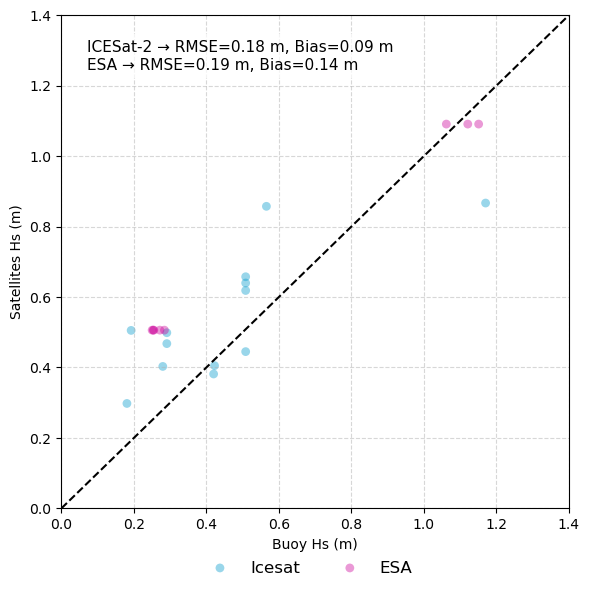

In [154]:
obs1 = df_atl12_buoy["buoy_hs"].values
mod1 = df_atl12_buoy["atl_hs"].values

obs2 = df_buoy_esa["buoy_hs"].values
mod2 = df_buoy_esa["esa_hs"].values

rmse1 = np.sqrt(mean_squared_error(obs1, mod1))
bias1 = np.mean(mod1 - obs1)

rmse2 = np.sqrt(mean_squared_error(obs2, mod2))
bias2 = np.mean(mod2 - obs2)


vmin,vmax = 0, 1.4
# 1:1 line range

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(obs1, mod1,c='#0099cc', s=40, alpha=0.4, edgecolor="none", label="Icesat")
ax.scatter(obs2, mod2,c='#cc0099', s=40, alpha=0.4, edgecolor="none", label="ESA")
# 1:1 line
ax.plot([vmin, vmax], [vmin, vmax], "k--", lw=1.5,)
textstr = (f"ICESat-2 → RMSE={rmse1:.2f} m, Bias={bias1:.2f} m \n"
           f"ESA → RMSE={rmse2:.2f} m, Bias={bias2:.2f} m")

ax.text(0.05, 0.95, textstr, transform=ax.transAxes,
        fontsize=11, va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
# Labels & formatting
ax.set_xlabel("Buoy Hs (m)")
ax.set_ylabel("Satellites Hs (m)")

ax.set_xlim(vmin, vmax)
ax.set_ylim(vmin, vmax)
ax.legend( loc="upper left", fontsize=12, bbox_to_anchor=(0.25,-0.075),ncol=2, frameon=False)
ax.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.savefig("/scratch/tmiesse/project/satellite/figures/hs_sat_buoy.png", dpi=300)
plt.show()